This file shows how to fit a simple sine function within $[-2\pi, 2\pi]$ using neural networks.

### Step 0: Setups
---

In [50]:
# To allow automatically uses the newest version of your code.  
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
# Add necessary paths to the system path
from utils import add_necessary_paths
add_necessary_paths()

# Import libraries
from utils import check_torch, fix_random_seed

import utils.u01 as u
import talos as ta
import torch
import numpy as np

# Do sanity checks before running the code
check_torch()

# Fix random seed for reproducibility
# NOTE: Run cells IN ORDER to ensure deterministic behavior.
fix_random_seed()

:: PyTorch version: 2.9.1+cu128
:: CUDA is available. Number of CUDA devices: 1
   - Device 0: NVIDIA GeForce RTX 5090


### Step 1: Prepare data
---

:: Dataset `sin(x)` (size: 200)
   - X: type=<class 'numpy.ndarray'>, shape=(200,)
   - Y: type=<class 'numpy.ndarray'>, shape=(200,)
:: Dataset `sin(x) (1/2)` (size: 100)
   - X: type=<class 'numpy.ndarray'>, shape=(100,)
   - Y: type=<class 'numpy.ndarray'>, shape=(100,)
:: Dataset `sin(x) (2/2)` (size: 100)
   - X: type=<class 'numpy.ndarray'>, shape=(100,)
   - Y: type=<class 'numpy.ndarray'>, shape=(100,)


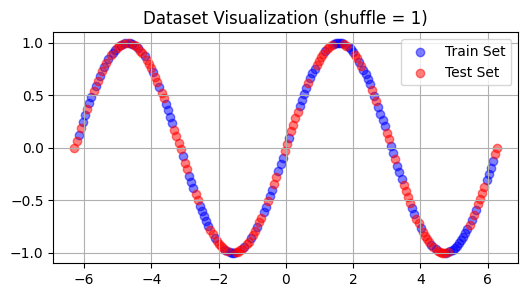

In [76]:
# configure data set  
t_min, t_max = -2 * np.pi, 2 * np.pi
n_points = 200
shuffle = 1
train_test_ratio = (1, 1)

# Generate data
X = np.linspace(t_min, t_max, n_points)
Y = np.sin(X)
dataset = ta.Dataset(X, Y, name='sin(x)')
dataset.report()

# Split data
train_set, test_set = dataset.split(*train_test_ratio, shuffle=shuffle)
train_set.report()
test_set.report()

# Visualize data
ax = u.get_axis((6, 3))
u.plot_points(ax, train_set.X, train_set.Y, 'blue', 'Train Set')
u.plot_points(ax, test_set.X, test_set.Y, 'red', 'Test Set')
u.finalize_plot(ax, title=f'Dataset Visualization (shuffle = {shuffle})')

### Step 2: Build model
---